<a href="https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/Week_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**Name:** C Vinusha Reddy

**USN:** 1CR22IS036  

**Task:** Task-4  

**Week:** 10


https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/Week_10.ipynb

#  Project Title  
### Potato Leaf Disease Detection using Image Classification

#  Project Description
This project focuses on building an image classification model to detect and classify potato plant diseases.  
The dataset consists of high-resolution images of potato leaves categorized into three classes:  
Early Blight, Late Blight, and Healthy leaves.  

The goal is to develop a robust deep learning model that can accurately identify plant diseases and support agricultural diagnostics.

#  Objectives
- Understand image classification using deep learning  
- Perform data preprocessing and augmentation  
- Train and evaluate a CNN-based model  

#  Dataset Details
## Classes:
- Early Blight  
- Late Blight  
- Healthy  

## Data Type:
Image dataset (high-resolution leaf images)

###**1. Import Libraries**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

import kagglehub
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

###**2. Load Dataset**

In [ ]:
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Dataset Path:", path)

# Use correct folder
data_path = os.path.join(path, "PotatoPlants")
print("Using Path:", data_path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Dataset Path: /kaggle/input/potato-plant-diseases-data
Using Path: /kaggle/input/potato-plant-diseases-data/PotatoPlants


###**3. Data Understanding**

In [ ]:
classes = os.listdir(data_path)
print("Classes:", classes)
print("Number of classes:", len(classes))

for cls in classes:
    print(cls, "-->", len(os.listdir(os.path.join(data_path, cls))))

Classes: ['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']
Number of classes: 3
Potato___healthy --> 152
Potato___Late_blight --> 1000
Potato___Early_blight --> 1000


###**4. Visualize Images**

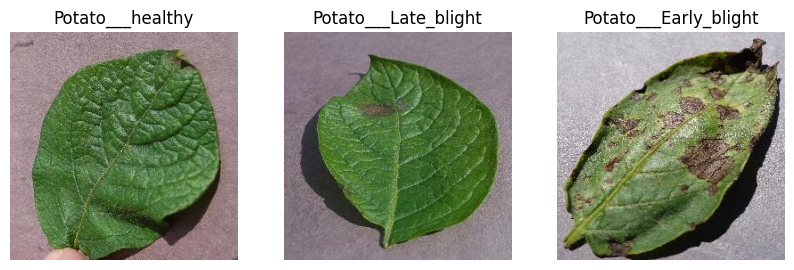

In [ ]:
plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    img_path = os.path.join(data_path, cls, os.listdir(os.path.join(data_path, cls))[0])
    img = Image.open(img_path)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

###**5. Create DataFrame**

In [ ]:
data = []

for label in classes:
    class_path = os.path.join(data_path, label)
    for img in os.listdir(class_path):
        data.append([os.path.join(class_path, img), label])

data = pd.DataFrame(data, columns=['img_path', 'label'])
data = data.sample(frac=1, random_state=42)

print(data.head())

                                               img_path                  label
1505  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___Early_blight
1660  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___Early_blight
889   /kaggle/input/potato-plant-diseases-data/Potat...   Potato___Late_blight
306   /kaggle/input/potato-plant-diseases-data/Potat...   Potato___Late_blight
1771  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___Early_blight


###**6. Train / Validation / Test Split**

In [ ]:
train_data, temp_data = train_test_split(data, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(len(train_data), len(val_data), len(test_data))

1506 323 323


###**7. Data Preprocessing**

In [ ]:
img_size = (128,128)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_data,
    x_col='img_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = test_datagen.flow_from_dataframe(
    val_data,
    x_col='img_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_dataframe(
    test_data,
    x_col='img_path',
    y_col='label',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1506 validated image filenames belonging to 3 classes.
Found 323 validated image filenames belonging to 3 classes.
Found 323 validated image filenames belonging to 3 classes.


###**8. Model Building**

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(len(classes), activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

###**9. Model Training**

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.6753 - loss: 0.6990 - val_accuracy: 0.8173 - val_loss: 0.4598
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8712 - loss: 0.3365 - val_accuracy: 0.8885 - val_loss: 0.2966
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9290 - loss: 0.2002 - val_accuracy: 0.8297 - val_loss: 0.3860
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9416 - loss: 0.1689 - val_accuracy: 0.6749 - val_loss: 0.9843
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9110 - loss: 0.2293 - val_accuracy: 0.9071 - val_loss: 0.2435
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9535 - loss: 0.1357 - val_accuracy: 0.9381 - val_loss: 0.1715
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9482 - loss: 0.1329 - val_accuracy: 0.9350 - val_loss: 0.1883
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9469 - loss: 0.1407 - val_accuracy: 0.8731 - val_loss:

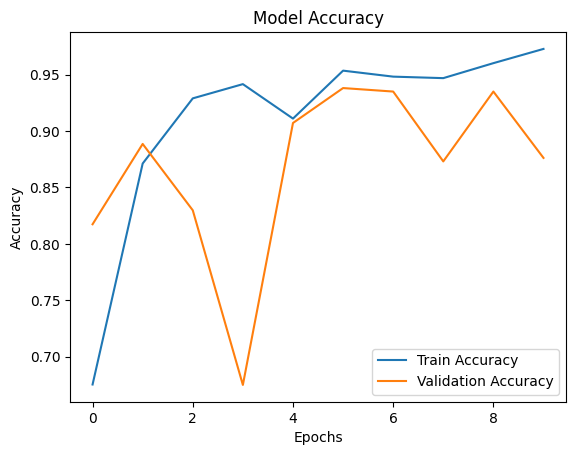

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

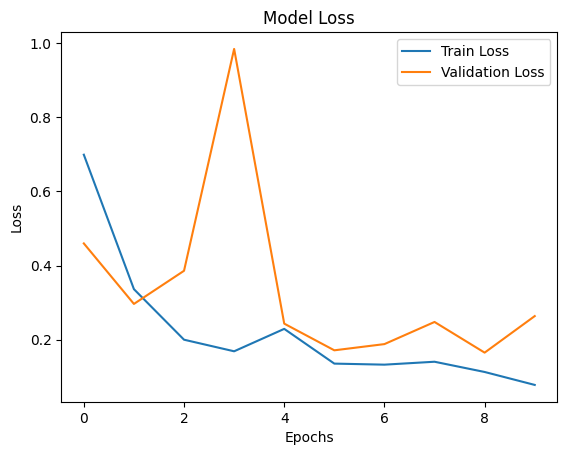

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - accuracy: 0.9164 - loss: 0.1579
Test Accuracy: 0.9164086580276489
Test Loss: 0.15790502727031708


###**10. Model Evaluation**

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - accuracy: 0.9164 - loss: 0.1579
Test Accuracy: 0.9164086580276489
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step


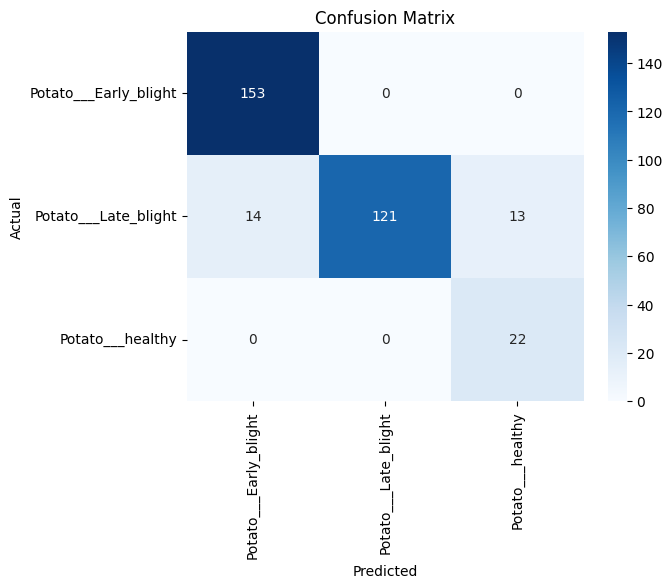


Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.92      1.00      0.96       153
 Potato___Late_blight       1.00      0.82      0.90       148
     Potato___healthy       0.63      1.00      0.77        22

             accuracy                           0.92       323
            macro avg       0.85      0.94      0.88       323
         weighted avg       0.93      0.92      0.92       323



In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

y_pred = model.predict(test_gen)
y_pred = np.argmax(y_pred, axis=1)

y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))